In [14]:
import os
import torch
import torch.nn as nn
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, Callback
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [15]:
class ResidualConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, padding=0),
            nn.BatchNorm2d(out_channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.shortcut(x))

In [16]:
class UNetV5(pl.LightningModule):
    def __init__(self, in_channels=3, out_classes=1, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # Encoder
        self.down1, self.down2 = ResidualConv(in_channels, 64), ResidualConv(64, 128)
        self.down3, self.down4 = ResidualConv(128, 256), ResidualConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = ResidualConv(512, 1024)
        
        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = ResidualConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = ResidualConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = ResidualConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = ResidualConv(128, 64)
        
        self.final_conv = nn.Conv2d(64, out_classes, 1)
        self.bce = nn.BCEWithLogitsLoss()
        
        # To store values for the Loss Curve
        self.train_losses, self.val_losses = [], []

    def forward(self, x):
        s1 = self.down1(x); p1 = self.pool(s1)
        s2 = self.down2(p1); p2 = self.pool(s2)
        s3 = self.down3(p2); p3 = self.pool(s3)
        s4 = self.down4(p3); p4 = self.pool(s4)
        bn = self.bottleneck(p4)
        d4 = self.conv4(torch.cat([self.up4(bn), s4], dim=1))
        d3 = self.conv3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.conv2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.conv1(torch.cat([self.up1(d2), s1], dim=1))
        return self.final_conv(d1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        # Hybrid Loss: BCE + Dice
        p = torch.sigmoid(y_hat)
        dice_loss = 1 - (2.*(p*y).sum() + 1e-7) / (p.sum() + y.sum() + 1e-7)
        loss = self.bce(y_hat, y) + dice_loss
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.train_losses.append(self.trainer.callback_metrics["train_loss"].item())

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        p = torch.sigmoid(y_hat)
        v_loss = self.bce(y_hat, y) + (1 - (2.*(p*y).sum() + 1e-7) / (p.sum() + y.sum() + 1e-7))
        dice = (2.*((p>0.5)*y).sum() + 1e-7) / ((p>0.5).sum() + y.sum() + 1e-7)
        iou = ((p>0.5)*y).sum() / (((p>0.5) + y > 0).sum() + 1e-7)
        self.log_dict({"val_loss": v_loss, "val_dice": dice, "val_iou": iou}, prog_bar=True)

    def on_validation_epoch_end(self):
        if "val_loss" in self.trainer.callback_metrics:
            self.val_losses.append(self.trainer.callback_metrics["val_loss"].item())

    def configure_optimizers(self): return torch.optim.Adam(self.parameters(), lr=self.lr)


In [17]:
class FinalBrainDataset(Dataset):
    def __init__(self, imgs, masks, transform=None):
        self.imgs, self.masks, self.transform = imgs, masks, transform
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = cv2.resize(cv2.cvtColor(cv2.imread(self.imgs[i]), cv2.COLOR_BGR2RGB), (256, 256))
        mask = cv2.resize(cv2.imread(self.masks[i], 0), (256, 256)) / 255.0
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img.float()/255., mask.unsqueeze(0).float()

/home/linux-hasan/projects/envs/pt/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2686/3226936481.py:10: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type              | Params | Mode  | FLOPs
------------------------------------------------------------------
0  | down1      | ResidualConv      | 39.4 K | train | 0    
1  | down2      | R

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


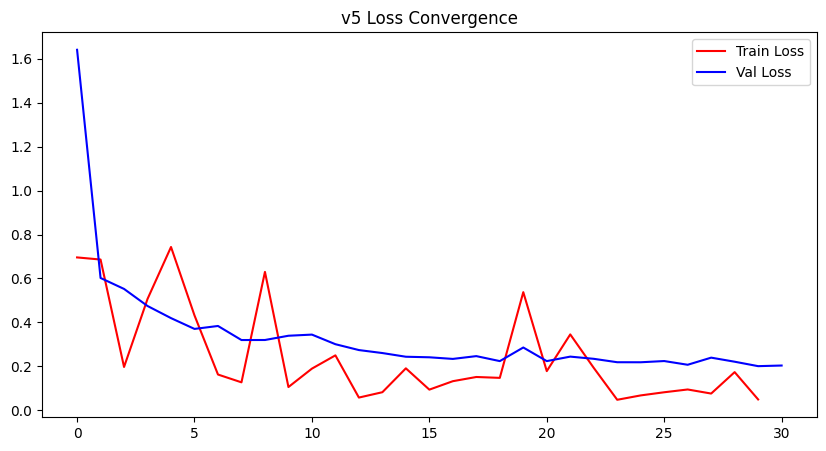

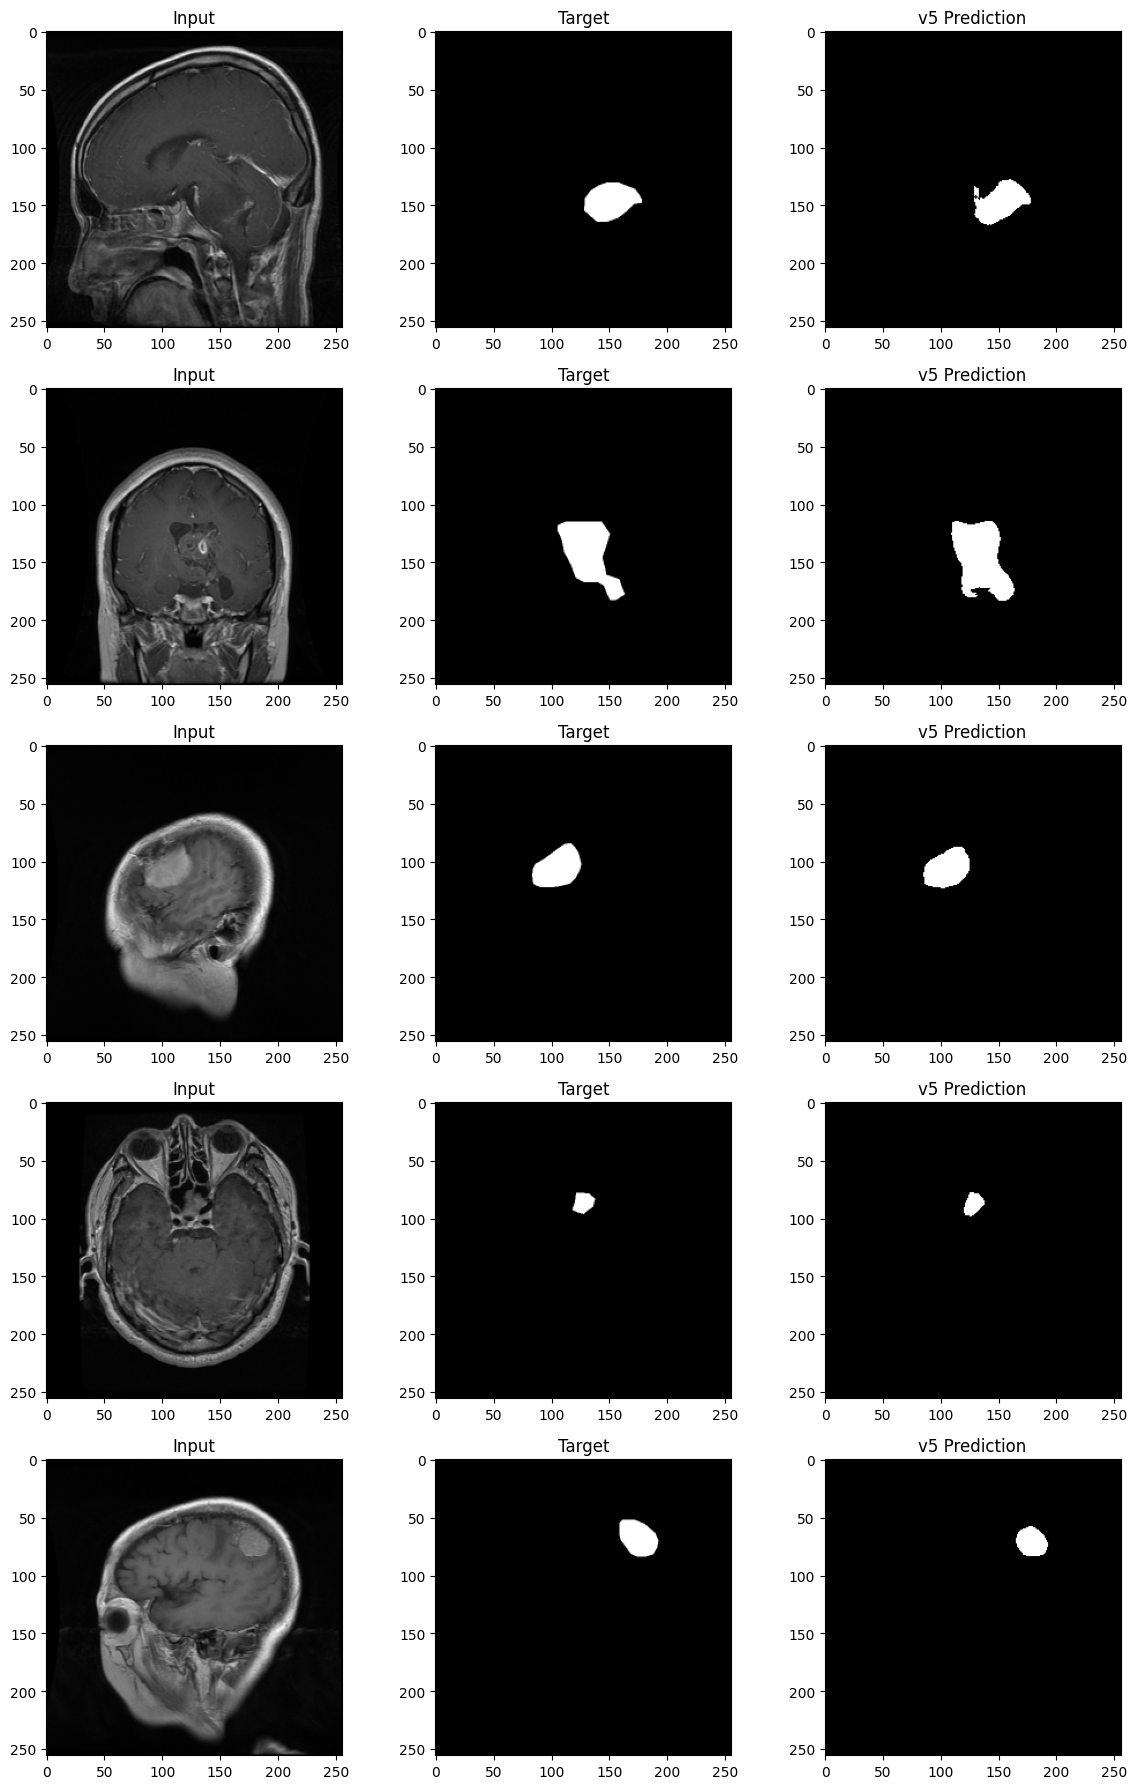

In [18]:
def run_final_experiment():
    img_list = sorted(glob("dataset/images/*.png"))
    mask_list = sorted(glob("dataset/masks/*.png"))
    
    # Advanced Augmentation (as recommended by the paper) [cite: 68, 125]
    train_aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
        ToTensorV2()
    ])
    val_aug = A.Compose([ToTensorV2()])
    
    ds = FinalBrainDataset(img_list, mask_list)
    tr_len = int(len(ds)*0.8); vl_len = int(len(ds)*0.1)
    train, val, test = random_split(ds, [tr_len, vl_len, len(ds)-tr_len-vl_len])
    train.dataset.transform = train_aug
    val.dataset.transform = val_aug; test.dataset.transform = val_aug
    
    model = UNetV5()
    checkpoint = ModelCheckpoint(monitor="val_dice", mode="max", save_top_k=1, filename="best_v5")
    
    # Text Logging Callback
    class FinalLogger(Callback):
        def on_validation_epoch_end(self, trainer, pl_module):
            m = trainer.callback_metrics
            with open("v5_final_metrics.txt", "a") as f:
                f.write(f"Epoch {trainer.current_epoch}: Loss {m.get('val_loss'):.4f} | Dice {m.get('val_dice'):.4f} | IoU {m.get('val_iou'):.4f}\n")

    trainer = pl.Trainer(max_epochs=30, callbacks=[checkpoint, FinalLogger()], accelerator="auto")
    trainer.fit(model, DataLoader(train, batch_size=8, shuffle=True), DataLoader(val, batch_size=8))

    # 4. Generate Results and Visuals
    plt.figure(figsize=(10, 5))
    plt.plot(model.train_losses, color='red', label='Train Loss')
    plt.plot(model.val_losses, color='blue', label='Val Loss')
    plt.title("v5 Loss Convergence"); plt.legend(); plt.savefig("v5_loss_curve.png"); plt.show()

    best_model = UNetV5.load_from_checkpoint(checkpoint.best_model_path)
    best_model.to("cuda" if torch.cuda.is_available() else "cpu").eval()
    
    fig, axes = plt.subplots(5, 3, figsize=(12, 18))
    for i in range(5):
        img, mask = test[i]
        with torch.no_grad():
            pred = torch.sigmoid(best_model(img.unsqueeze(0).to(best_model.device))) > 0.5
        axes[i,0].imshow(img.permute(1,2,0)); axes[i,0].set_title("Input")
        axes[i,1].imshow(mask.squeeze(), cmap='gray'); axes[i,1].set_title("Target")
        axes[i,2].imshow(pred.squeeze().cpu(), cmap='gray'); axes[i,2].set_title("v5 Prediction")
    plt.tight_layout(); plt.savefig("v5_results_grid.png"); plt.show()

if __name__ == "__main__":
    run_final_experiment()